<a href="https://colab.research.google.com/github/qiyuriko/ICT304-Assignment1/blob/main/ICT304_Preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
!unzip -q /content/bird_data.zip -d /content/
print("Unzip completed.")

Unzip completed.


In [7]:
import os
from collections import Counter

base_path = "/content/bird_data"

for part in ["color", "segmentation"]:
    print(f"\n--- {part.upper()} ---")

    part_path = os.path.join(base_path, part)

    for folder in os.listdir(part_path):
        folder_path = os.path.join(part_path, folder)

        if os.path.isdir(folder_path):
            files = os.listdir(folder_path)
            extensions = Counter(os.path.splitext(f)[1].lower() for f in files)

            print(folder)
            print("Total files:", len(files))
            print("Formats:", extensions)


--- COLOR ---
089.Hooded_Merganser
Total files: 60
Formats: Counter({'.jpg': 60})
087.Mallard
Total files: 60
Formats: Counter({'.jpg': 60})

--- SEGMENTATION ---
089.Hooded_Merganser
Total files: 60
Formats: Counter({'.png': 60})
087.Mallard
Total files: 60
Formats: Counter({'.png': 60})


In [8]:
from PIL import Image
import os

base_path = "/content/bird_data"

for part in ["color", "segmentation"]:
    corrupted = []

    part_path = os.path.join(base_path, part)

    for folder in os.listdir(part_path):
        folder_path = os.path.join(part_path, folder)

        if os.path.isdir(folder_path):
            for file in os.listdir(folder_path):
                file_path = os.path.join(folder_path, file)

                try:
                    with Image.open(file_path) as img:
                        img.verify()
                except Exception:
                    corrupted.append(file_path)

    print(f"{part} corrupted images:", len(corrupted))

color corrupted images: 0
segmentation corrupted images: 0


In [9]:
from PIL import Image
import os
from collections import Counter

base_path = "/content/bird_data"

for part in ["color", "segmentation"]:
    sizes = []
    modes = []

    part_path = os.path.join(base_path, part)

    for folder in os.listdir(part_path):
        folder_path = os.path.join(part_path, folder)

        if os.path.isdir(folder_path):
            for file in os.listdir(folder_path):
                file_path = os.path.join(folder_path, file)

                with Image.open(file_path) as img:
                    sizes.append(img.size)
                    modes.append(img.mode)

    print(f"\n--- {part.upper()} ---")
    print("Image sizes:", Counter(sizes))
    print("Color modes:", Counter(modes))


--- COLOR ---
Image sizes: Counter({(500, 375): 21, (500, 333): 18, (500, 332): 6, (500, 334): 5, (500, 400): 4, (500, 330): 3, (500, 500): 2, (500, 318): 2, (333, 500): 2, (500, 340): 2, (500, 376): 2, (500, 300): 1, (500, 346): 1, (500, 337): 1, (500, 344): 1, (500, 335): 1, (500, 286): 1, (372, 500): 1, (500, 320): 1, (500, 240): 1, (500, 302): 1, (400, 300): 1, (500, 357): 1, (500, 338): 1, (500, 342): 1, (500, 374): 1, (450, 300): 1, (428, 500): 1, (400, 265): 1, (400, 234): 1, (432, 288): 1, (400, 267): 1, (500, 348): 1, (484, 460): 1, (500, 307): 1, (500, 371): 1, (500, 379): 1, (447, 500): 1, (450, 339): 1, (400, 400): 1, (500, 312): 1, (500, 463): 1, (485, 500): 1, (450, 403): 1, (500, 279): 1, (500, 351): 1, (500, 352): 1, (500, 353): 1, (374, 500): 1, (500, 272): 1, (469, 500): 1, (500, 381): 1, (500, 354): 1, (417, 500): 1, (500, 363): 1, (500, 305): 1, (500, 434): 1, (500, 399): 1, (500, 361): 1, (444, 500): 1, (500, 385): 1, (500, 317): 1, (500, 359): 1, (500, 293): 1})


In [10]:
from PIL import Image
import os

color_path = "/content/bird_data/color"

for folder in os.listdir(color_path):
    folder_path = os.path.join(color_path, folder)

    for file in os.listdir(folder_path):
        file_path = os.path.join(folder_path, file)

        with Image.open(file_path) as img:
            if img.mode != "RGB":
                print("Non-RGB image:", file_path)
                print("Mode:", img.mode)

Non-RGB image: /content/bird_data/color/087.Mallard/Mallard_0130_76836.jpg
Mode: L


In [11]:
import os

base_path = "/content/bird_data"

for bird_class in ["087.Mallard", "089.Hooded_Merganser"]:
    color_folder = os.path.join(base_path, "color", bird_class)
    seg_folder = os.path.join(base_path, "segmentation", bird_class)

    color_names = {
        os.path.splitext(f)[0]
        for f in os.listdir(color_folder)
    }

    seg_names = {
        os.path.splitext(f)[0]
        for f in os.listdir(seg_folder)
    }

    missing_seg = color_names - seg_names
    missing_color = seg_names - color_names

    print(f"\n--- {bird_class} ---")
    print("Color images:", len(color_names))
    print("Segmentation images:", len(seg_names))
    print("Missing segmentation:", len(missing_seg))
    print("Missing color:", len(missing_color))


--- 087.Mallard ---
Color images: 60
Segmentation images: 60
Missing segmentation: 0
Missing color: 0

--- 089.Hooded_Merganser ---
Color images: 60
Segmentation images: 60
Missing segmentation: 0
Missing color: 0


In [12]:
import os
import hashlib

base_path = "/content/bird_data"

for part in ["color", "segmentation"]:
    hashes = {}
    duplicates = []

    part_path = os.path.join(base_path, part)

    for folder in os.listdir(part_path):
        folder_path = os.path.join(part_path, folder)

        if os.path.isdir(folder_path):
            for file in os.listdir(folder_path):
                file_path = os.path.join(folder_path, file)

                with open(file_path, "rb") as f:
                    file_hash = hashlib.md5(f.read()).hexdigest()

                if file_hash in hashes:
                    duplicates.append((hashes[file_hash], file_path))
                else:
                    hashes[file_hash] = file_path

    print(f"{part} duplicate images:", len(duplicates))

color duplicate images: 0
segmentation duplicate images: 0


In [13]:
from PIL import Image
import os

base_path = "/content/bird_data"
output_base = "/content/bird_data/preprocessed"
target_size = 224

def to_square(img, size=224, resample=Image.BICUBIC):
    w, h = img.size
    scale = size / max(w, h)
    img = img.resize((round(w * scale), round(h * scale)), resample)
    fill = 0 if img.mode == "L" else (0, 0, 0)
    canvas = Image.new(img.mode, (size, size), fill)
    canvas.paste(img, ((size - img.width) // 2, (size - img.height) // 2))
    return canvas

for part in ["color", "segmentation"]:
    resample = Image.BICUBIC if part == "color" else Image.NEAREST
    input_part = os.path.join(base_path, part)
    output_part = os.path.join(output_base, part)

    for bird_class in os.listdir(input_part):
        input_folder = os.path.join(input_part, bird_class)
        output_folder = os.path.join(output_part, bird_class)
        os.makedirs(output_folder, exist_ok=True)

        for file in os.listdir(input_folder):
            input_file = os.path.join(input_folder, file)
            output_file = os.path.join(output_folder, file)

            with Image.open(input_file) as img:
                img = img.convert("RGB" if part == "color" else "L")
                img = to_square(img, target_size, resample)
                img.save(output_file)

print("Preprocessing completed.")

Preprocessing completed.


In [14]:
from PIL import Image
import os
from collections import Counter

base_path = "/content/bird_data/preprocessed"

for part in ["color", "segmentation"]:
    sizes = []
    modes = []
    total = 0

    part_path = os.path.join(base_path, part)

    for folder in os.listdir(part_path):
        folder_path = os.path.join(part_path, folder)

        if os.path.isdir(folder_path):
            for file in os.listdir(folder_path):
                file_path = os.path.join(folder_path, file)

                with Image.open(file_path) as img:
                    sizes.append(img.size)
                    modes.append(img.mode)
                    total += 1

    print(f"\n--- {part.upper()} ---")
    print("Total images:", total)
    print("Sizes:", Counter(sizes))
    print("Modes:", Counter(modes))


--- COLOR ---
Total images: 120
Sizes: Counter({(224, 224): 120})
Modes: Counter({'RGB': 120})

--- SEGMENTATION ---
Total images: 120
Sizes: Counter({(224, 224): 120})
Modes: Counter({'L': 120})


In [15]:
import os
from collections import Counter

base = "/content/bird_data/preprocessed/color"
print(Counter({c: len(os.listdir(os.path.join(base, c))) for c in os.listdir(base)}))

Counter({'089.Hooded_Merganser': 60, '087.Mallard': 60})


In [16]:
from torchvision import transforms, models

weights = models.EfficientNet_B0_Weights.IMAGENET1K_V1
val_tf = weights.transforms()

train_tf = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15, fill=0),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0), ratio=(0.9, 1.1)),
    transforms.ToTensor(),
    transforms.Normalize(mean=weights.transforms().mean,
                         std=weights.transforms().std),
])


In [17]:
import torch

print("CUDA available:", torch.cuda.is_available())
print("Device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

CUDA available: True
Device: Tesla T4


In [18]:
from torchvision import datasets, transforms, models
import numpy as np
from sklearn.model_selection import StratifiedKFold

weight = models.EfficientNet_B0_Weights.IMAGENET1K_V1
norm = weights.transforms()

train_tf = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15, fill=0),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0), ratio=(0.9, 1.1)),
    transforms.ToTensor(),
    transforms.Normalize(mean=norm.mean, std=norm.std),
])
val_tf = norm

dataset = datasets.ImageFolder("/content/bird_data/preprocessed/color", transform=train_tf)
print("Classes: ", dataset.class_to_idx)
print("Total images: ", len(dataset))
targets = np.array(dataset.targets)

Classes:  {'087.Mallard': 0, '089.Hooded_Merganser': 1}
Total images:  120


In [19]:
import torch
import torch.nn as nn

## Loading pre-trained network which already knows edges, textures, shapes, etc..
def build_model():
    model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
    model.classifier = nn.Sequential(
        nn.Dropout(0.4),
        nn.Linear(1280, 2), ## first param - pooled feature size, second param - num of classes
    )
    ## Reduce num of parameters trained to about 2,562
    for p in model.features.parameters():
        p.requires_grad = False
    return model

m = build_model()
print("Trainable: ", sum(p.numel() for p in m.parameters() if p.requires_grad))

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 157MB/s]

Trainable:  2562


In [20]:
## For Training
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, n = 0.0, 0, 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad() ## Clearing last step's gradients
        outputs = model(images) ## Forward passing raw scores
        loss = criterion(outputs, labels) ## How wrong the model is currently
        loss.backward() ## Calculate gradient's direction
        optimizer.step() ## Nudging the weights backwards through network

        total_loss += loss.item() * labels.size(0)
        correct += (outputs.argmax(1) == labels).sum().item() ## Picks whether 0 or 1 higher score = predicted class
        n += labels.size(0)

    return total_loss / n, correct / n

In [21]:
## For Validation
@torch.no_grad() ## No gradient tracking as no updates are necessary
def evaluate(model, loader, criterion, device):
    model.eval() ## Putting layers into inference mode
    total_loss, correct, n = 0.0, 0, 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)

        total_loss += loss.item() * labels.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()
        n += labels.size(0)

    return total_loss / n, correct / n

In [22]:
from torch.utils.data import DataLoader, Subset
from torch.optim import AdamW
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

EPOCHS = 25
BATCH_SIZE = 16
fold_results = []

for fold, (train_idx, val_idx) in enumerate(skf.split(np.zeros(len(targets)), targets)):
    print(f"\n======= Fold {fold+1}/5 =======")

    torch.manual_seed(42 + fold)

    train_ds = Subset(datasets.ImageFolder(
        "/content/bird_data/preprocessed/color", transform=train_tf), train_idx)
    val_ds = Subset(datasets.ImageFolder(
        "/content/bird_data/preprocessed/color", transform=val_tf), val_idx)

    train_loader = DataLoader(train_ds, batch_size = BATCH_SIZE, shuffle=True, num_workers=2)
    val_loader = DataLoader(val_ds, batch_size = BATCH_SIZE, shuffle=False, num_workers=2)

    model = build_model().to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = AdamW(filter(lambda p: p.requires_grad, model.parameters()),
                      lr=1e-3, weight_decay=1e-4)

    best_val_loss, best_acc = float("inf"), 0.0

    for epoch in range(EPOCHS):
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)

        if val_loss < best_val_loss:
           best_val_loss, best_acc = val_loss, val_acc
           torch.save(model.state_dict(), f"/content/best_fold{fold+1}.pt")

        print(f"epoch {epoch+1:2d} | train {train_loss:.3f}/{train_acc:.3f} | val {val_loss:.3f}/{val_acc:.3f}")

    print(f"Fold {fold+1} best val acc: {best_acc:.3f}")
    fold_results.append((best_acc))

print(f"\nCV accuracy: {np.mean(fold_results):.3f} ± {np.std(fold_results):.3f}")


======= Fold 1/5 =======
epoch  1 | train 0.681/0.562 | val 0.654/0.750
epoch  2 | train 0.548/0.833 | val 0.490/0.875
epoch  3 | train 0.453/0.844 | val 0.414/0.875
epoch  4 | train 0.404/0.906 | val 0.384/0.875
epoch  5 | train 0.363/0.896 | val 0.373/0.875
epoch  6 | train 0.417/0.833 | val 0.359/0.875
epoch  7 | train 0.297/0.906 | val 0.342/0.875
epoch  8 | train 0.300/0.917 | val 0.323/0.875
epoch  9 | train 0.262/0.938 | val 0.300/0.833
epoch 10 | train 0.246/0.938 | val 0.299/0.875
epoch 11 | train 0.235/0.958 | val 0.309/0.875
epoch 12 | train 0.234/0.969 | val 0.297/0.833
epoch 13 | train 0.216/0.948 | val 0.285/0.833
epoch 14 | train 0.216/0.969 | val 0.288/0.875
epoch 15 | train 0.195/0.958 | val 0.273/0.875
epoch 16 | train 0.203/0.938 | val 0.290/0.833
epoch 17 | train 0.175/0.938 | val 0.277/0.875
epoch 18 | train 0.210/0.948 | val 0.262/0.875
epoch 19 | train 0.154/0.979 | val 0.266/0.875
epoch 20 | train 0.133/1.000 | val 0.254/0.875
epoch 21 | train 0.159/0.958 | val

In [23]:
## Unfreezing backbone so that features adapt to the mallards and mergansers
## Which looks diffrerent from the ImageNet classes the backbone was trained on

def build_model(unfreeze_blocks=2):
    model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
    model.classifier = nn.Sequential(
        nn.Dropout(0.4),
        nn.Linear(1280, 2), ## first param - pooled feature size, second param - num of classes
    )
    if unfreeze_blocks:
        for block in model.features[:unfreeze_blocks]:
            for p in block.parameters():
                p.requires_grad = True
    return model

In [24]:
from torch.utils.data import DataLoader, Subset
from torch.optim import AdamW
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

EPOCHS = 25
BATCH_SIZE = 16
fold_results = []

for fold, (train_idx, val_idx) in enumerate(skf.split(np.zeros(len(targets)), targets)):
    print(f"\n======= Fold {fold+1}/5 =======")

    torch.manual_seed(42 + fold)

    train_ds = Subset(datasets.ImageFolder(
        "/content/bird_data/preprocessed/color", transform=train_tf), train_idx)
    val_ds = Subset(datasets.ImageFolder(
        "/content/bird_data/preprocessed/color", transform=val_tf), val_idx)

    train_loader = DataLoader(train_ds, batch_size = BATCH_SIZE, shuffle=True, num_workers=2)
    val_loader = DataLoader(val_ds, batch_size = BATCH_SIZE, shuffle=False, num_workers=2)

    model = build_model().to(device)
    criterion = nn.CrossEntropyLoss()
    ## Here, using a discriminative learning rate (different lr depending on change):
    ## - Smaller for the unfrozen EfficientNet block
    ## - Larger for the the new classification head)
    optimizer = AdamW([
        {"params": [p for p in model.features.parameters() if p.requires_grad], "lr": 1e-4},
        {"params": model.classifier.parameters(), "lr": 1e-3},
    ], weight_decay=1e-4)

    best_val_loss, best_acc = float("inf"), 0.0

    for epoch in range(EPOCHS):
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)

        if val_loss < best_val_loss:
           best_val_loss, best_acc = val_loss, val_acc
           torch.save(model.state_dict(), f"/content/best_fold{fold+1}.pt")

        print(f"epoch {epoch+1:2d} | train {train_loss:.3f}/{train_acc:.3f} | val {val_loss:.3f}/{val_acc:.3f}")

    print(f"Fold {fold+1} best val acc: {best_acc:.3f}")
    fold_results.append((best_acc))

print(f"\nCV accuracy: {np.mean(fold_results):.3f} ± {np.std(fold_results):.3f}")


======= Fold 1/5 =======
epoch  1 | train 0.629/0.630 | val 0.523/0.750
epoch  2 | train 0.415/0.944 | val 0.288/0.917
epoch  3 | train 0.267/0.944 | val 0.212/0.917
epoch  4 | train 0.159/0.981 | val 0.195/1.000
epoch  5 | train 0.087/1.000 | val 0.170/0.917
epoch  6 | train 0.089/0.991 | val 0.171/0.917
epoch  7 | train 0.075/0.981 | val 0.168/0.917
epoch  8 | train 0.037/1.000 | val 0.162/0.917
epoch  9 | train 0.027/1.000 | val 0.156/0.917
epoch 10 | train 0.026/1.000 | val 0.149/0.917
epoch 11 | train 0.008/1.000 | val 0.131/0.917
epoch 12 | train 0.013/1.000 | val 0.128/0.917
epoch 13 | train 0.016/1.000 | val 0.119/0.917
epoch 14 | train 0.042/1.000 | val 0.109/0.917
epoch 15 | train 0.019/0.991 | val 0.065/1.000
epoch 16 | train 0.009/1.000 | val 0.062/1.000
epoch 17 | train 0.020/1.000 | val 0.071/0.917
epoch 18 | train 0.011/1.000 | val 0.053/1.000
epoch 19 | train 0.007/1.000 | val 0.044/1.000
epoch 20 | train 0.012/0.991 | val 0.041/1.000
epoch 21 | train 0.002/1.000 | val

In [25]:
## The held-out test so that images are unseen and the CV accuracy is reliable
## Holding out ~20 images before the CV loop and running the CV on the remaining 100
from torch.utils.data import Subset
from sklearn.model_selection import train_test_split

full = datasets.ImageFolder("/content/bird_data/preprocessed/color", transform=val_tf)
targets = np.array(full.targets)
idx_all = np.arange(len(full))

# 20 held out, stratified by class, fixed seed so the split is reproducible
idx_trainval, idx_test = train_test_split(
    idx_all, test_size=20, stratify=targets, random_state=42
)

print("Train/val pool:", len(idx_trainval), "| Held-out test:", len(idx_test))
print("Test class counts:", np.bincount(targets[idx_test]))

Train/val pool: 100 | Held-out test: 20
Test class counts: [10 10]


In [26]:
## Build this once
test_ds = Subset(datasets.ImageFolder(
    "/content/bird_data/preprocessed/color", transform=val_tf), idx_test)
test_loader = DataLoader(test_ds, batch_size=16, shuffle=False, num_workers=2)

In [49]:
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import train_test_split ## <-- for held-out test
from torch.optim import AdamW
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42) ## <-- Folds back to 5

EPOCHS = 25
BATCH_SIZE = 16
fold_results = []

# full dataset for paths/classes; targets already exists as np.array
full = datasets.ImageFolder("/content/bird_data/preprocessed/color", transform=val_tf)
targets = np.array(full.targets)
idx_all = np.arange(len(full))

idx_trainval, idx_test = train_test_split(
    idx_all, test_size=20, stratify=targets, random_state=42
)

print("Pool:", len(idx_trainval), "| Held out:", len(idx_test))
print("Test class counts:", np.bincount(targets[idx_test]))   # Expected [10 10]

tv_targets = targets[idx_trainval]

for fold, (train_idx, val_idx) in enumerate(skf.split(idx_trainval, tv_targets)):

    ## Remapping each fold's train_idx to real indices in the dataset
    train_idx = idx_trainval[train_idx]
    val_idx   = idx_trainval[val_idx]

    print(f"\n======= Fold {fold+1}/5 =======")

    torch.manual_seed(42 + fold)

    train_ds = Subset(datasets.ImageFolder(
        "/content/bird_data/preprocessed/color", transform=train_tf), train_idx)
    val_ds = Subset(datasets.ImageFolder(
        "/content/bird_data/preprocessed/color", transform=val_tf), val_idx)

    train_loader = DataLoader(train_ds, batch_size = BATCH_SIZE, shuffle=True, num_workers=2)
    val_loader = DataLoader(val_ds, batch_size = BATCH_SIZE, shuffle=False, num_workers=2)

    model = build_model().to(device)
    criterion = nn.CrossEntropyLoss()
    ## Here, using a discriminative learning rate (different lr depending on change):
    ## - Smaller for the unfrozen EfficientNet block
    ## - Larger for the the new classification head)
    optimizer = AdamW([
        {"params": [p for p in model.features.parameters() if p.requires_grad], "lr": 1e-4},
        {"params": model.classifier.parameters(), "lr": 1e-3},
    ], weight_decay=1e-4)

    best_val_loss, best_acc = float("inf"), 0.0

    for epoch in range(EPOCHS):
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)

        if val_loss < best_val_loss:
           best_val_loss, best_acc = val_loss, val_acc
           torch.save(model.state_dict(), f"/content/best_fold{fold+1}.pt")

        print(f"epoch {epoch+1:2d} | train {train_loss:.3f}/{train_acc:.3f} | val {val_loss:.3f}/{val_acc:.3f}")

    print(f"Fold {fold+1} best val acc: {best_acc:.3f}")
    fold_results.append((best_acc))

print(f"\nCV accuracy: {np.mean(fold_results):.3f} ± {np.std(fold_results):.3f}")

Pool: 100 | Held out: 20
Test class counts: [10 10]

======= Fold 1/5 =======
epoch  1 | train 0.641/0.688 | val 0.578/0.850
epoch  2 | train 0.509/0.825 | val 0.384/0.900
epoch  3 | train 0.364/0.938 | val 0.249/0.950
epoch  4 | train 0.278/0.950 | val 0.177/0.950
epoch  5 | train 0.211/0.963 | val 0.142/0.950
epoch  6 | train 0.105/1.000 | val 0.105/0.950
epoch  7 | train 0.096/0.988 | val 0.082/0.950
epoch  8 | train 0.110/0.975 | val 0.058/1.000
epoch  9 | train 0.062/0.988 | val 0.048/1.000
epoch 10 | train 0.034/1.000 | val 0.041/1.000
epoch 11 | train 0.021/1.000 | val 0.036/1.000
epoch 12 | train 0.015/1.000 | val 0.033/1.000
epoch 13 | train 0.025/1.000 | val 0.033/1.000
epoch 14 | train 0.077/0.950 | val 0.024/1.000
epoch 15 | train 0.031/0.975 | val 0.023/1.000
epoch 16 | train 0.007/1.000 | val 0.022/1.000
epoch 17 | train 0.009/1.000 | val 0.021/1.000
epoch 18 | train 0.008/1.000 | val 0.022/1.000
epoch 19 | train 0.007/1.000 | val 0.020/1.000
epoch 20 | train 0.008/1.000 

In [51]:
## Held-out test reporting (if the model will generalize to 40 new images 10/10 split)
import torch.nn.functional as F
from sklearn.metrics import classification_report, confusion_matrix

test_ds = Subset(datasets.ImageFolder(
    "/content/bird_data/preprocessed/color", transform=val_tf), idx_test)
test_loader = DataLoader(test_ds, batch_size=16, shuffle=False, num_workers=2)

probs_all = []
for fold in range(5):
    m = build_model(unfreeze_blocks=1).to(device)
    m.load_state_dict(torch.load(f"/content/best_fold{fold+1}.pt"))
    m.eval()
    fold_probs = []
    with torch.no_grad():
        for images, _ in test_loader:
            fold_probs.append(F.softmax(m(images.to(device)), dim=1).cpu())
    probs_all.append(torch.cat(fold_probs))

preds = torch.stack(probs_all).mean(0).argmax(1)
labels_all = torch.tensor(targets[idx_test])

print(f"Test accuracy: {(preds == labels_all).float().mean():.3f} "
      f"({(preds == labels_all).sum().item()}/{len(idx_test)})")
print(classification_report(labels_all, preds, target_names=list(full.classes), digits=3))
print(confusion_matrix(labels_all, preds))

Test accuracy: 0.950 (19/20)
                      precision    recall  f1-score   support

         087.Mallard      1.000     0.900     0.947        10
089.Hooded_Merganser      0.909     1.000     0.952        10

            accuracy                          0.950        20
           macro avg      0.955     0.950     0.950        20
        weighted avg      0.955     0.950     0.950        20

[[ 9  1]
 [ 0 10]]


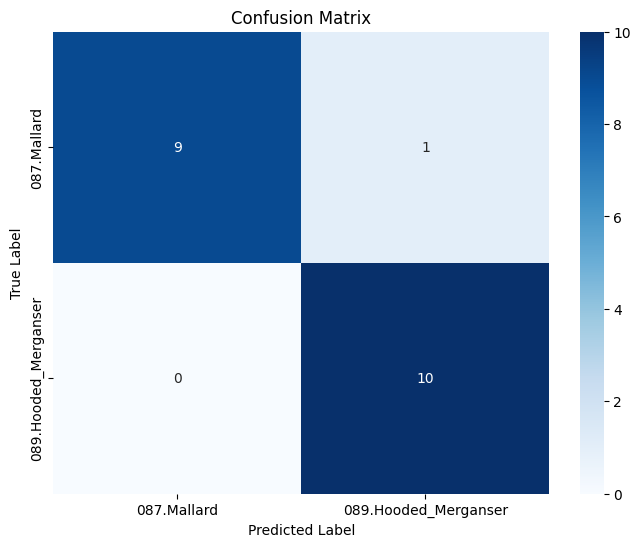

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(labels_all, preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=list(full.classes), yticklabels=list(full.classes))
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

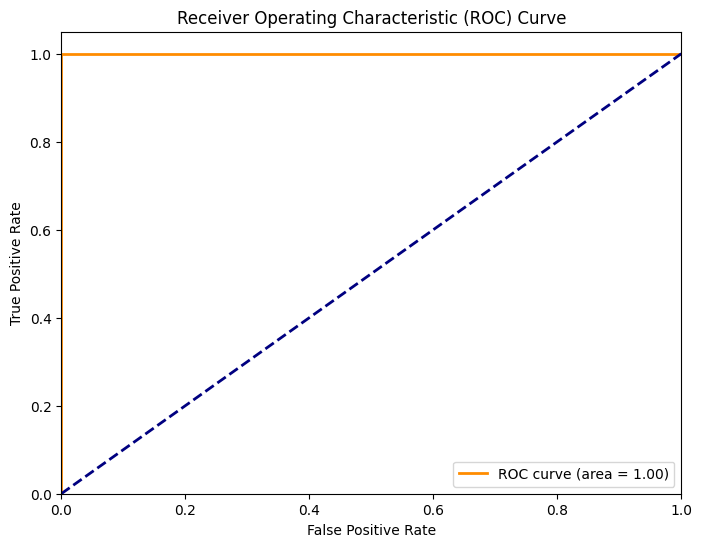

In [53]:
from sklearn.metrics import roc_curve, auc

# Assuming `probs_all` from previous cells contains the probabilities for each fold.
# We need the probability of the positive class (class 1 for '089.Hooded_Merganser')
# which is the second column of the `preds_all` tensor.

# Average probabilities across folds if `probs_all` is a list of tensors
# Otherwise, if `probs_all` is already the stacked probabilities, use it directly.
# The `preds` from the previous cell was argmax, we need the raw probabilities.
# Let's re-calculate the average probabilities for the test set.

# Re-run the test evaluation to get the raw probabilities
re_probs_all = []
for fold in range(5):
    m = build_model(unfreeze_blocks=1).to(device)
    m.load_state_dict(torch.load(f"/content/best_fold{fold+1}.pt"))
    m.eval()
    fold_probs = []
    with torch.no_grad():
        for images, _ in test_loader:
            fold_probs.append(F.softmax(m(images.to(device)), dim=1).cpu())
    re_probs_all.append(torch.cat(fold_probs))

average_probs = torch.stack(re_probs_all).mean(0)
preds_prob_positive = average_probs[:, 1].numpy() # Probability of class 1

# `labels_all` (true labels) should be available from previous cells

fpr, tpr, thresholds = roc_curve(labels_all, preds_prob_positive)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()

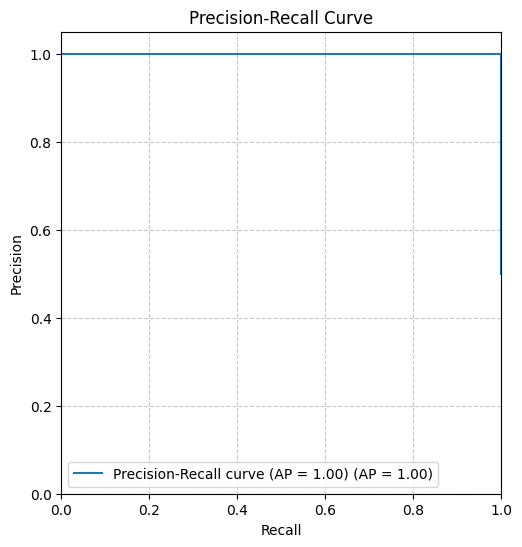

In [54]:
from sklearn.metrics import precision_recall_curve, auc, PrecisionRecallDisplay

# `labels_all` and `preds_prob_positive` are already available from the ROC curve calculation

precision, recall, _ = precision_recall_curve(labels_all, preds_prob_positive)
ap_score = auc(recall, precision)

plt.figure(figsize=(8, 6))
# Use PrecisionRecallDisplay for a cleaner plot, it also plots a no-skill line by default.
# The `pos_label` argument is important if the positive class is not 1.
# In this case, `preds_prob_positive` corresponds to class 1, so `pos_label` is implicitly handled.
pr_display = PrecisionRecallDisplay(precision=precision, recall=recall, average_precision=ap_score)
pr_display.plot(ax=plt.gca(), name=f'Precision-Recall curve (AP = {ap_score:.2f})')

plt.title('Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.legend(loc='lower left')
plt.show()

### Interactive Image Classification

Below are 6 images from a small sample of the held-out test set (3 'Hooded Merganser' and 3 'Mallard'). Click the "Select" button next to an image to have the model classify it and display its prediction along with the confidence.

In [55]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import random
from PIL import Image
import torch.nn.functional as F

# Ensure `full`, `targets`, `idx_test`, `val_tf`, `build_model`, `device` are defined from previous cells

# Select 3 images from each class from the held-out test set
mallard_indices = [i for i in idx_test if targets[i] == full.class_to_idx['087.Mallard']]
merganser_indices = [i for i in idx_test if targets[i] == full.class_to_idx['089.Hooded_Merganser']]

selected_mallards = random.sample(mallard_indices, min(3, len(mallard_indices)))
selected_mergansers = random.sample(merganser_indices, min(3, len(merganser_indices)))

interactive_indices = selected_mallards + selected_mergansers
random.shuffle(interactive_indices) # Shuffle for mixed display

# List to hold the widgets for display
interactive_items = []

# Output widget for displaying classification results
output_widget = widgets.Output()

def classify_image_button_handler(b, img_path_val, true_label_name_val):
    with output_widget:
        clear_output(wait=True)
        img_path = img_path_val
        true_label_name = true_label_name_val

        # Removed: print(f"Selected image: {img_path}")
        print(f"True label: {true_label_name}")

        # Load and preprocess the image
        img = Image.open(img_path).convert("RGB")
        img_tensor = val_tf(img).unsqueeze(0).to(device)

        # Perform classification using the ensemble of models
        ensemble_probs = []
        for fold in range(5):
            model = build_model(unfreeze_blocks=1).to(device) # Re-initialize model
            model.load_state_dict(torch.load(f"/content/best_fold{fold+1}.pt"))
            model.eval()
            with torch.no_grad():
                output = model(img_tensor)
                ensemble_probs.append(F.softmax(output, dim=1).cpu())

        avg_probs = torch.stack(ensemble_probs).mean(0).squeeze().numpy()
        predicted_class_idx = avg_probs.argmax()
        predicted_class_name = full.classes[predicted_class_idx]
        confidence = avg_probs[predicted_class_idx]

        # Display the image and prediction with new feedback
        plt.figure(figsize=(6, 6))
        plt.imshow(img)
        plt.title(f"The image contains a bird which is likely a {predicted_class_name} (Confidence: {confidence:.2f})\nTrue: {true_label_name}")
        plt.axis('off')
        plt.show()

# Loop through interactive_indices to create image displays and buttons
for i, idx in enumerate(interactive_indices):
    img_path, true_label_idx = full.samples[idx]
    true_label_name = full.classes[true_label_idx]

    # Create a PIL Image object to display and resize it
    img_pil = Image.open(img_path).convert("RGB").resize((150, 150))

    # Create a button for this image
    select_button = widgets.Button(description="Select")

    # Use a lambda to pass the specific img_path and true_label_name to the handler
    select_button.on_click(lambda b, ip=img_path, tl=true_label_name: classify_image_button_handler(b, ip, tl))

    # Create an ipywidgets.Image for displaying the PIL image
    # The value must be the raw image data (e.g., PNG bytes)
    from io import BytesIO
    buffer = BytesIO()
    img_pil.save(buffer, format='PNG')
    img_widget = widgets.Image(
        value=buffer.getvalue(),
        format='png',
        width=150,
        height=150,
    )

    # Add descriptive text below the image (True label)
    description_text = widgets.HTML(value=f"<b>True: {true_label_name}</b>")

    # Arrange image and button vertically
    interactive_items.append(widgets.VBox([img_widget, select_button]))

# Display all interactive image-button sets horizontally
display(widgets.HBox(interactive_items))

# Display the output widget where classification results will appear
display(output_widget)

Output()